In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
def nullcount(df):
    nullcounts={}
    for col in df:
        nullcounts[col] = df[col].isnull().sum()
    return nullcounts

# EDA

## Data Shape and Size

In [3]:
df = pd.read_csv('capstone_data.csv') #Load the data

In [4]:
df.shape # Data shape (rows, columns)

(284, 644)

In [5]:
df.head(5) # Data preview

,State_Name,State_District_Name,AA_Sample_Units_Total,AA_Sample_Units_Rural,AA_Sample_Units_Urban,AA_Households_Total,AA_Households_Rural,AA_Households_Urban,AA_Population_Total,AA_Population_Rural,...,ZZ_Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Total_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Total_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit
0,Assam,Barpeta,53,47,6,13711,12765,946,64606,60293,...,54,70,NaN,NaN,871,985,851,965,908.0,1611.0
1,Assam,Bongaigaon,89,73,16,17384,14904,2480,84012,73899,...,58,73,NaN,NaN,897,1005,911,1026,621.0,956.0
2,Assam,Cachar,105,84,21,27488,24207,3281,127158,112171,...,68,80,31.0,57.0,891,966,871,949,905.0,1168.0
3,Assam,Darrang,26,24,2,5951,5769,182,29048,28256,...,79,107,NaN,NaN,913,1102,908,1097,NaN,NaN
4,Assam,Dhemaji,121,108,13,14481,12619,1862,75451,66537,...,40,53,11.0,38.0,935,1045,938,1054,772.0,1083.0


In [6]:
# List the states
states = list(df.State_Name.unique())
print(len(states))
states

9


['Assam',
 'Bihar',
 'Chhattisgarh',
 'Jharkhand',
 'Madhya Pradesh',
 'Odisha',
 'Rajasthan',
 'Uttar Pradesh',
 'Uttarakhand']

## Target Variable Inspection

In [17]:
# General statistics of the target variabel
pd.DataFrame(df.YY_Infant_Mortality_Rate_Imr_Total_Person.describe())

# median is roughly equal to the mean

,YY_Infant_Mortality_Rate_Imr_Total_Person
count,284.000000
mean,56.178028
std,14.094372
min,19.220000
25%,47.950000
50%,55.000000
75%,65.180000
max,97.000000


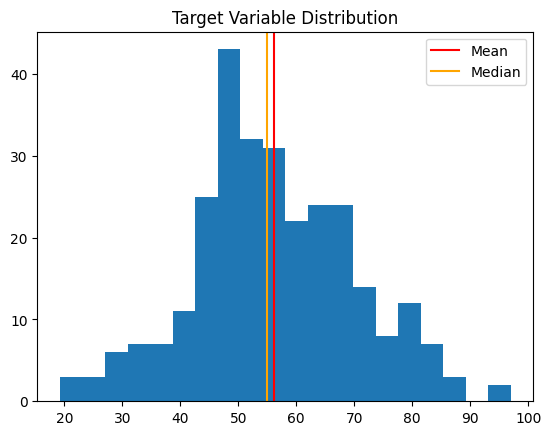

In [18]:
## Target Variable Distribution
plt.hist(df.YY_Infant_Mortality_Rate_Imr_Total_Person, bins=20)
plt.axvline(df.YY_Infant_Mortality_Rate_Imr_Total_Person.mean(), color='red', label='Mean')
plt.axvline(df.YY_Infant_Mortality_Rate_Imr_Total_Person.median(), color='orange', label = 'Median')
plt.title('Target Variable Distribution'), plt.legend()
plt.show()

# Mostly normal with few notable outliers

In [21]:
## Target Variable Null values
df.YY_Infant_Mortality_Rate_Imr_Total_Person.isna().sum()

# 0 Null values to handle

0

## Correlation / Multicollinearity

Text(0.5, 1.0, 'Heatmap')

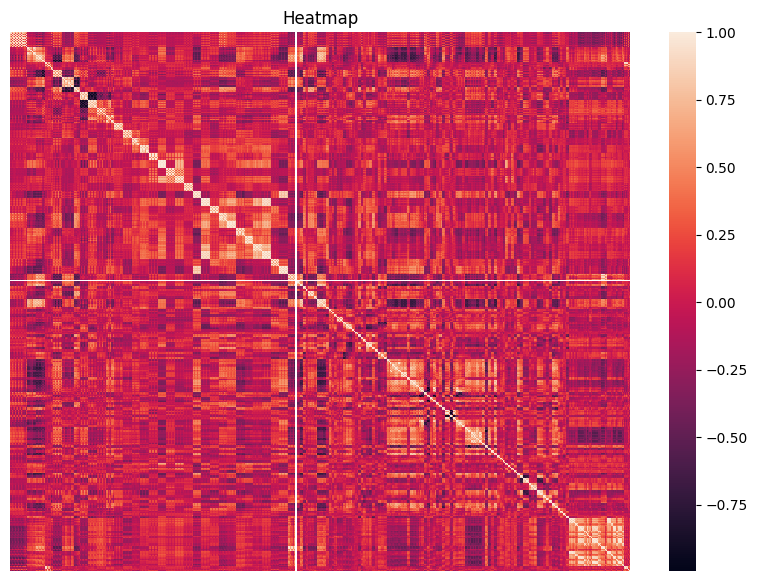

In [23]:
## Correlation overview
corr_mat = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr_mat, annot=False, xticklabels=False, yticklabels=False)
plt.title('Heatmap')

# Notable dark and light spots indicating multicollinearity

,AA_Sample_Units_Total,AA_Sample_Units_Rural,AA_Sample_Units_Urban,AA_Households_Total,AA_Households_Rural,AA_Households_Urban,AA_Population_Total,AA_Population_Rural,AA_Population_Urban,AA_Ever_Married_Women_Aged_15_49_Years_Total,AA_Ever_Married_Women_Aged_15_49_Years_Rural,AA_Ever_Married_Women_Aged_15_49_Years_Urban,AA_Currently_Married_Women_Aged_15_49_Years_Total,AA_Currently_Married_Women_Aged_15_49_Years_Rural,AA_Currently_Married_Women_Aged_15_49_Years_Urban,AA_Children_12_23_Months_Total,AA_Children_12_23_Months_Rural,AA_Children_12_23_Months_Urban
AA_Sample_Units_Total,1.000000,0.879744,0.664112,0.915218,0.794245,0.613484,0.872806,0.737195,0.593355,0.894308,0.764771,0.598304,0.888680,0.755545,0.597227,0.740040,0.611913,0.551351
AA_Sample_Units_Rural,0.879744,1.000000,0.228788,0.784546,0.879880,0.187966,0.741014,0.818504,0.161093,0.759552,0.845658,0.167570,0.753776,0.836991,0.166001,0.659826,0.693790,0.124889
AA_Sample_Units_Urban,0.664112,0.228788,1.000000,0.640218,0.242616,0.960531,0.621832,0.222319,0.961576,0.636709,0.236082,0.961524,0.634269,0.230820,0.961784,0.477663,0.161917,0.932502
AA_Households_Total,0.915218,0.784546,0.640218,1.000000,0.889939,0.632763,0.975385,0.853393,0.610511,0.983661,0.866031,0.614930,0.980768,0.860265,0.613224,0.851936,0.734709,0.559813
AA_Households_Rural,0.794245,0.879880,0.242616,0.889939,1.000000,0.209956,0.877945,0.972468,0.186031,0.878744,0.980350,0.190413,0.876981,0.976554,0.188347,0.814866,0.860395,0.145362


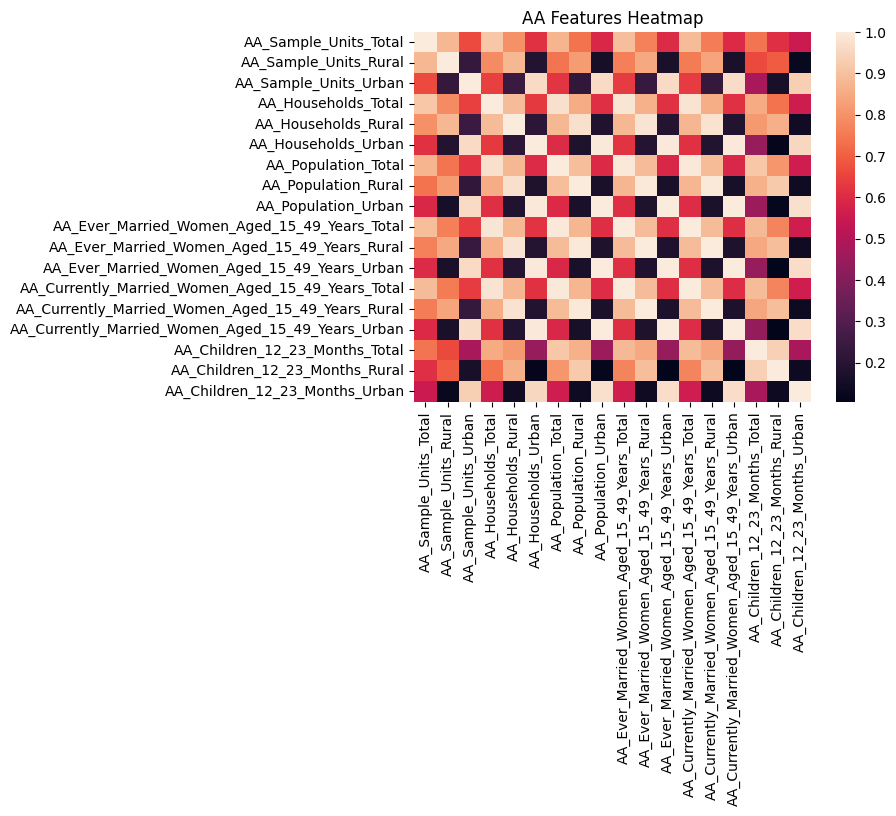

In [119]:
# Correlation between features with the "AA" identifier prefix
AA_inner_corr = corr_mat.filter(regex='^AA', axis=1).filter(regex='^AA', axis=0)

#plt.figure(figsize=(7,7))
sns.heatmap(AA_inner_corr)
plt.title('AA Features Heatmap')

AA_inner_corr.head()

,BB_Average_Household_Size_Sc_Total,BB_Average_Household_Size_Sc_Rural,BB_Average_Household_Size_Sc_Urban,BB_Average_Household_Size_St_Total,BB_Average_Household_Size_St_Rural,BB_Average_Household_Size_St_Urban,BB_Average_Household_Size_All_Total,BB_Average_Household_Size_All_Rural,BB_Average_Household_Size_All_Urban,BB_Population_Below_Age_15_Years_Total,BB_Population_Below_Age_15_Years_Rural,BB_Population_Below_Age_15_Years_Urban,BB_Dependency_Ratio_Total,BB_Dependency_Ratio_Rural,BB_Dependency_Ratio_Urban,BB_Currently_Married_Illiterate_Women_Aged_15_49_Years_Total,BB_Currently_Married_Illiterate_Women_Aged_15_49_Years_Rural,BB_Currently_Married_Illiterate_Women_Aged_15_49_Years_Urban
BB_Average_Household_Size_Sc_Total,1.000000,0.984270,0.796151,0.726258,0.698216,0.394749,0.938987,0.934909,0.824518,0.579340,0.598067,0.604419,0.540911,0.578763,0.581633,0.291749,0.280398,0.459754
BB_Average_Household_Size_Sc_Rural,0.984270,1.000000,0.731163,0.717212,0.700130,0.379278,0.919183,0.933614,0.774897,0.575431,0.594834,0.578612,0.538925,0.575653,0.561012,0.285219,0.266219,0.440976
BB_Average_Household_Size_Sc_Urban,0.796151,0.731163,1.000000,0.583208,0.543385,0.347385,0.784646,0.738370,0.834048,0.518705,0.522363,0.581423,0.496255,0.520537,0.565686,0.353571,0.342351,0.496570
BB_Average_Household_Size_St_Total,0.726258,0.717212,0.583208,1.000000,0.969936,0.479301,0.754171,0.751076,0.661962,0.487965,0.497953,0.463643,0.413982,0.429305,0.437290,0.280639,0.267638,0.355358
BB_Average_Household_Size_St_Rural,0.698216,0.700130,0.543385,0.969936,1.000000,0.371428,0.721246,0.734869,0.604488,0.449137,0.472511,0.407423,0.366512,0.392392,0.381275,0.251468,0.248917,0.315994


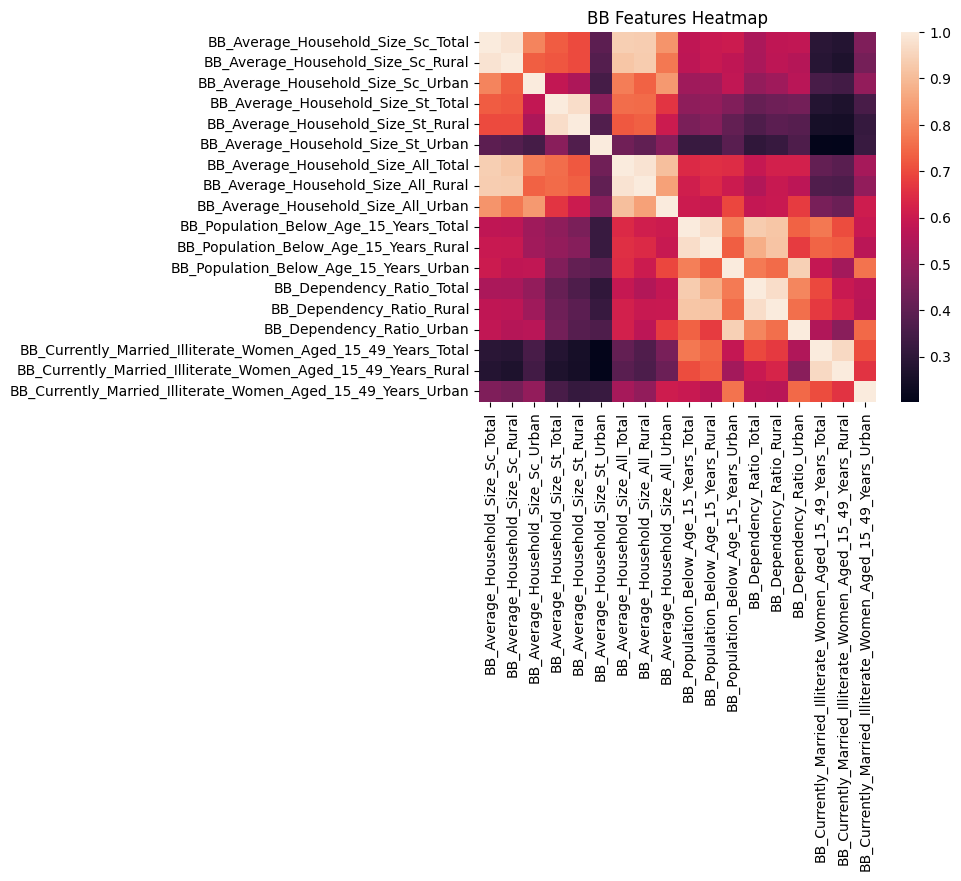

In [120]:
# Correlati0n between features with the "BB" identifier prefix
BB_inner_corr = corr_mat.filter(regex='^BB', axis=1).filter(regex='^BB', axis=0)

#plt.figure(figsize=(7,7))
sns.heatmap(BB_inner_corr)
plt.title('BB Features Heatmap')

BB_inner_corr.head()

# High multicollinearity between features with the same prefix

In [58]:
# Ordered correlation with target variable
target_corr = dict(df.select_dtypes(include='number').corr()['YY_Infant_Mortality_Rate_Imr_Total_Person'])
target_corr = sorted(target_corr.items(), key = lambda item: item[1])
target_corr

# Data leakage potential from near perfect correlation
# Numerous IMR features

[('AA_Ever_Married_Women_Aged_15_49_Years_Total', -0.46490693987258225),
 ('AA_Sample_Units_Total', -0.46264395007808556),
 ('AA_Currently_Married_Women_Aged_15_49_Years_Total', -0.46131720709828333),
 ('AA_Households_Total', -0.45026414495221373),
 ('AA_Population_Total', -0.43469756366175855),
 ('AA_Ever_Married_Women_Aged_15_49_Years_Rural', -0.38507912203215633),
 ('AA_Currently_Married_Women_Aged_15_49_Years_Rural', -0.3801038049079371),
 ('AA_Sample_Units_Rural', -0.37950860060501085),
 ('AA_Households_Rural', -0.37738595510442596),
 ('AA_Sample_Units_Urban', -0.3504900403988108),
 ('AA_Population_Rural', -0.3503945573299793),
 ('AA_Ever_Married_Women_Aged_15_49_Years_Urban', -0.33271477750463474),
 ('AA_Currently_Married_Women_Aged_15_49_Years_Urban', -0.33103614806887954),
 ('AA_Population_Urban', -0.32533802027461534),
 ('AA_Households_Urban', -0.324506241149795),
 ('AA_Children_12_23_Months_Urban', -0.3062868496789669),
 ('FF_Children_Currently_Attending_School_Age_6_17_Years

## Distributions of Numerical Values

In [47]:
# Columns representing totals; ie. variable_total vs variable_urban and variable_rural
col_totals=[]
for c in df.columns:
    if 'Total' in c:
        col_totals.append(c)
len(col_totals)

222

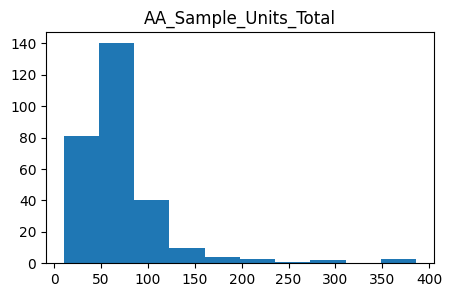

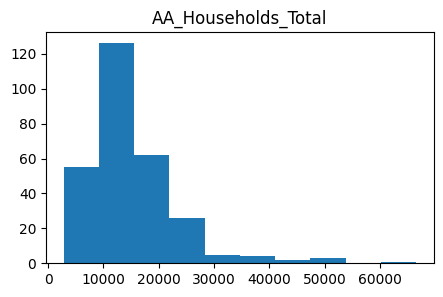

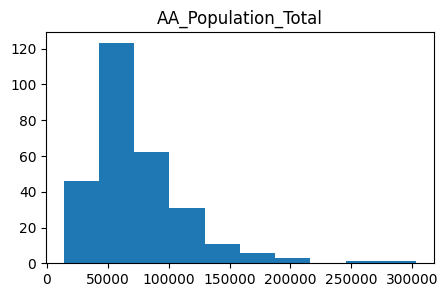

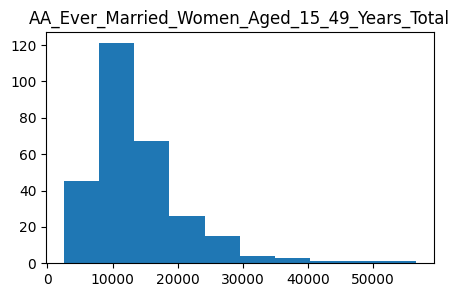

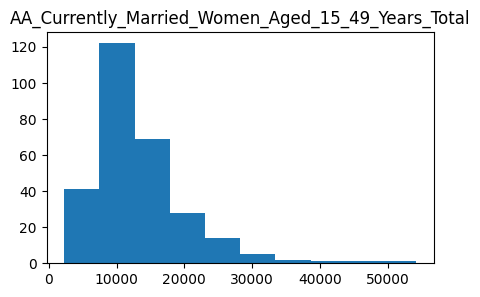

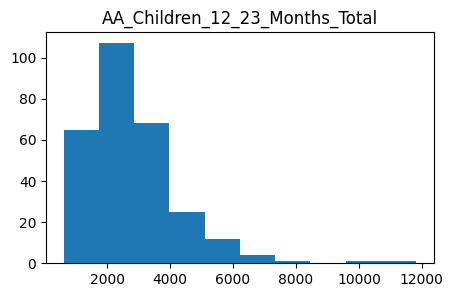

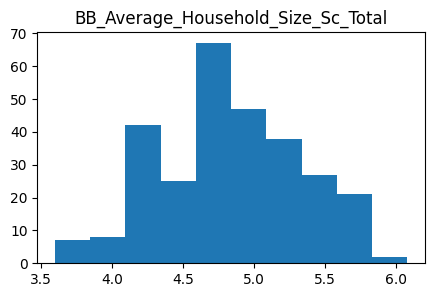

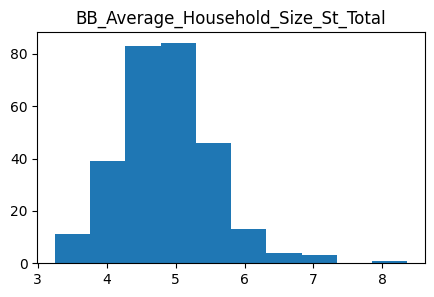

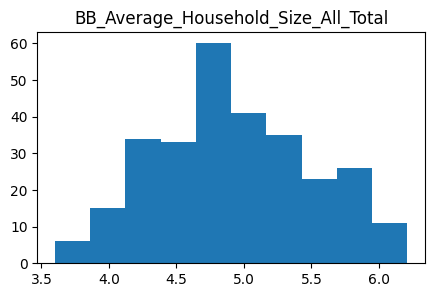

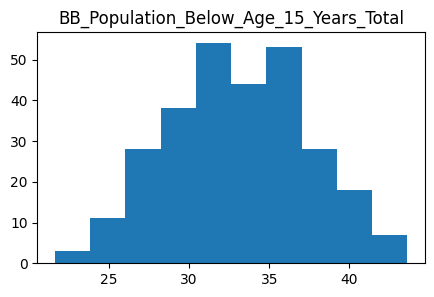

In [50]:
# Distributions for variable_total features (first 10)
for c in col_totals[:10]:
    plt.figure(figsize=(5,3))
    plt.hist(df[c]), plt.title(c)
    plt.show()

# Mix of normal and skewed feature distributions

## Null Values

In [51]:
## Null value counts for each feature with nulls
null_counts = nullcount(df)
has_null = dict()
for k,v in null_counts.items():
    if v>0:
        has_null[k]=v
sorted(has_null.items(), key = lambda item: item[1])

# Numerous features have the same number of null values

[('BB_Average_Household_Size_St_Urban', 1),
 ('LL_Crude_Birth_Rate_Cbr_Urban', 1),
 ('ZZ_Crude_Birth_Rate_Urban_Lower_Limit', 1),
 ('ZZ_Crude_Birth_Rate_Urban_Upper_Limit', 1),
 ('CC_Sex_Ratio_At_Birth_Urban', 3),
 ('LL_Natural_Growth_Rate_Urban', 3),
 ('YY_Crude_Death_Rate_Cdr_Urban_Person', 3),
 ('YY_Crude_Death_Rate_Cdr_Urban_Male', 3),
 ('YY_Crude_Death_Rate_Cdr_Urban_Female', 3),
 ('ZZ_Crude_Death_Rate_Urban_Lower_Limit', 3),
 ('ZZ_Crude_Death_Rate_Urban_Upper_Limit', 3),
 ('ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit', 9),
 ('ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit', 9),
 ('JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Acute_Respiratory_Infection_Ari_Person_Urban',
  44),
 ('JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Acute_Respiratory_Infection_Ari_Male_Urban',
  44),
 ('JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Acute_Respiratory_Infection_Ari_Female_Urban',
  44),
 ('JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_

In [52]:
## Number of features with nulls
len(has_null)

199

In [54]:
# Featues with NN prefix that have missing values
nn = []
for c in has_null:
    if 'NN_' in c:
        nn.append(c)

In [55]:
# Missing data for NN features
df[df['NN_Current_Usage_Any_Method_Urban'].isna()][nn].head(10)

# Note: Features are missing values for the same districts

,NN_Current_Usage_Any_Method_Urban,NN_Current_Usage_Any_Modern_Method_Urban,NN_Current_Usage_Female_Sterilization_Urban,NN_Current_Usage_Male_Sterilization_Urban,NN_Current_Usage_Copper_T_Iud_Urban,NN_Current_Usage_Pills_Urban,NN_Current_Usage_Condom_Nirodh_Urban,NN_Current_Usage_Emergency_Contraceptive_Pills_Urban,NN_Current_Usage_Any_Traditional_Method_Urban,NN_Current_Usage_Periodic_Abstinence_Urban,NN_Current_Usage_Withdrawal_Urban,NN_Current_Usage_Lam_Urban
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


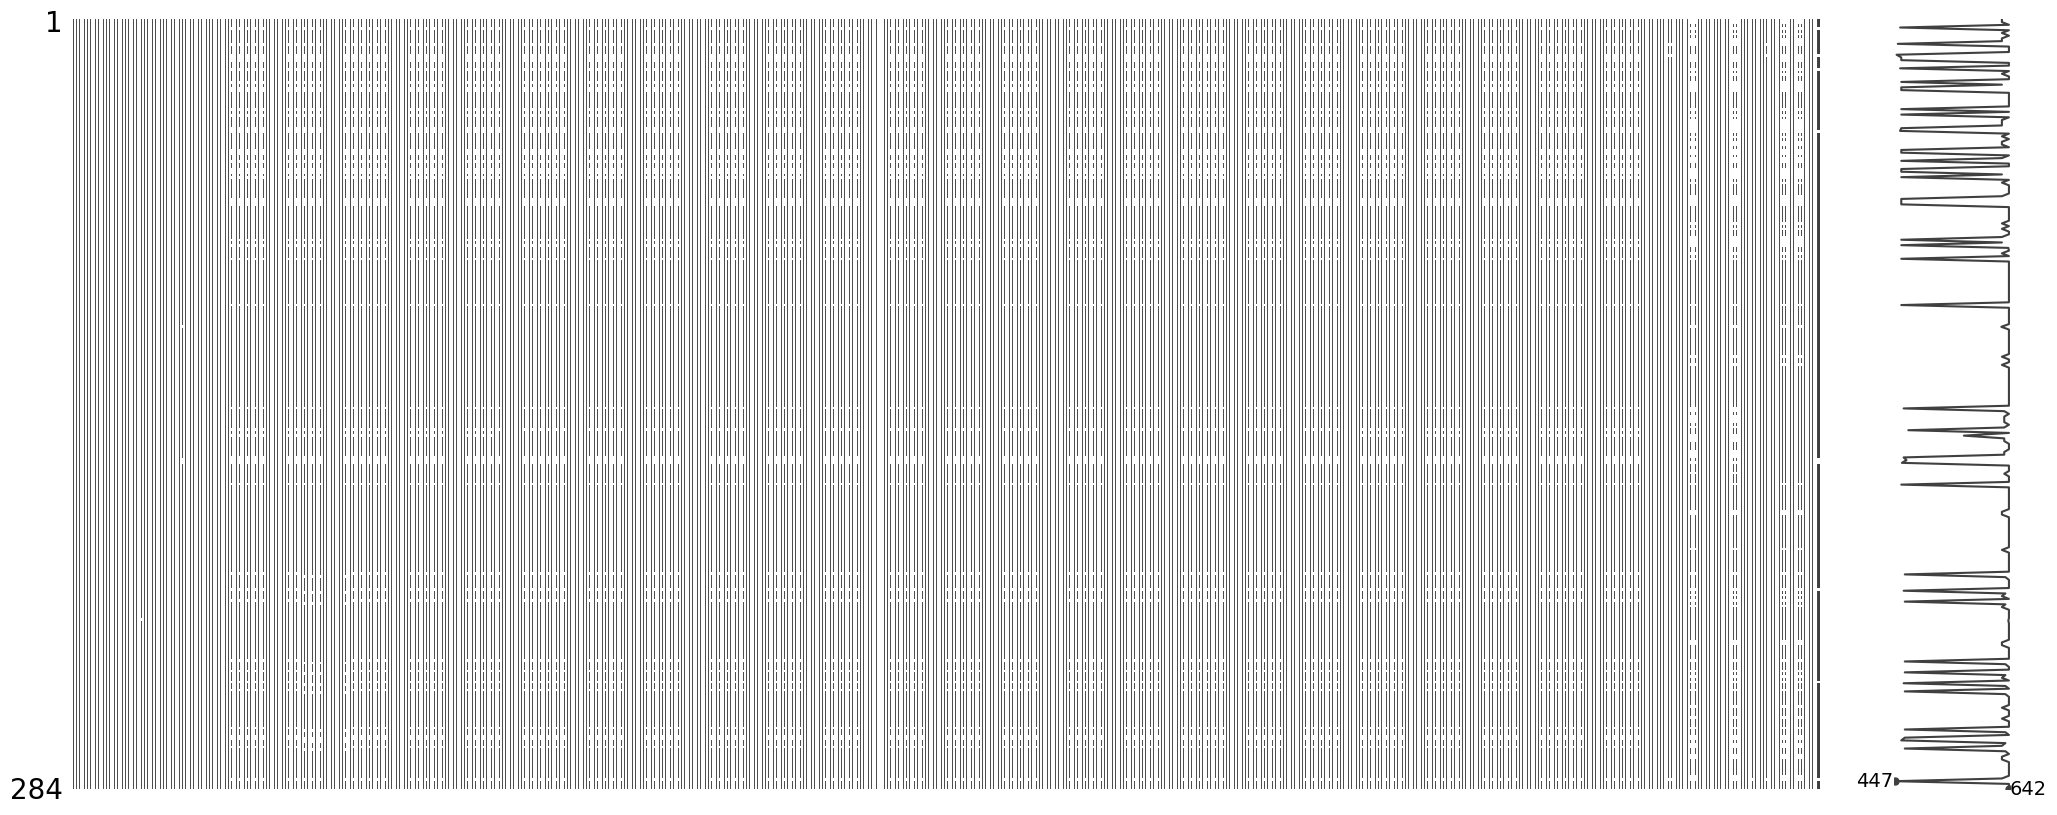

In [56]:
# Missingness matrix
msno.matrix(df)
plt.show()

# Uniform pattern in some areas

# Baseline Model

## Remove features redundant with the target
- Avoids data leakage and perfect results

In [59]:
# features to remove (correlation > 0.7)
target_corr_rem = dict(df.select_dtypes(include='number').corr()['YY_Infant_Mortality_Rate_Imr_Total_Person'])
remove = []

# Remove features redudant with target to prevent leakage
for k,v in target_corr_rem.items():
    if v > 0.7: # Specify correlation threshold
        remove.append(k)

remove.remove('YY_Infant_Mortality_Rate_Imr_Total_Person')

In [60]:
df = df.drop(remove, axis = 1)

## Baseline

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

In [62]:
base_model = LinearRegression() # Standard linear regression baseline model

In [63]:
# Split into X and y
X = df.drop('YY_Infant_Mortality_Rate_Imr_Total_Person', axis = 1)
y = df[['YY_Infant_Mortality_Rate_Imr_Total_Person']]

In [64]:
# one-hot categorical features (standard practice)
categorical = X.select_dtypes(include='object').columns
dums = pd.get_dummies(X[categorical])
X = pd.concat([X, dums], axis=1)
X = X.drop(categorical, axis=1)

In [65]:
# shape after one-hot
X.shape

(284, 912)

In [66]:
X = X.dropna(axis=1) # drop columns with null values for baseline

In [67]:
# Shape after removing nulls
X.shape

(284, 713)

In [68]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [69]:
# fit base model and predict on train and test sets
base_model.fit(X_train, y_train)
base_preds_train = base_model.predict(X_train)
base_preds_test = base_model.predict(X_test)

In [71]:
# Baseline metrics: r2, RMSE
train_r2 = r2_score(y_train, base_preds_train)
test_r2 = r2_score(y_test, base_preds_test)

# Adjusted r2
n = X_train.shape[0]; p = X_train.shape[1]
train_adj_r2 = 1 - (1-train_r2) * (n-1) / (n-p-1)
n = X_test.shape[0]; p = X_test.shape[1]
test_adj_r2 = 1 - (1-test_r2) * (n-1)/ (n-p-1)

train_RMSE = mean_squared_error(y_train, base_preds_train)
test_RMSE = mean_squared_error(y_test, base_preds_test)

train_ape = mean_absolute_percentage_error(y_train, base_preds_train)
test_ape = mean_absolute_percentage_error(y_test, base_preds_test)

print('Train r2:', train_r2)
print('Train Adjusted r2:', train_adj_r2)
print('Train RMSE:', train_RMSE)
print('Test Adjusted r2:', test_adj_r2)
print('Test r2:', test_r2)
print('Test RMSE:', test_RMSE)
print(train_ape)
print(test_ape)

# Perfect training metrics
# Test metrics are worse than predicting the mean (r^2 < 0)

Train r2: 1.0
Train Adjusted r2: 1.0
Train RMSE: 5.606653300951082e-23
Test Adjusted r2: 1.2046512222269323
Test r2: -0.5120113830413355
Test RMSE: 364.55035299889556
9.420211718957683e-14
0.27844498046334165


In [72]:
train_sorted_index = y_train.reset_index(drop=True).sort_values(by='YY_Infant_Mortality_Rate_Imr_Total_Person').index
ordered_preds_train = pd.DataFrame(base_preds_train).reindex(train_sorted_index).loc[:][0]

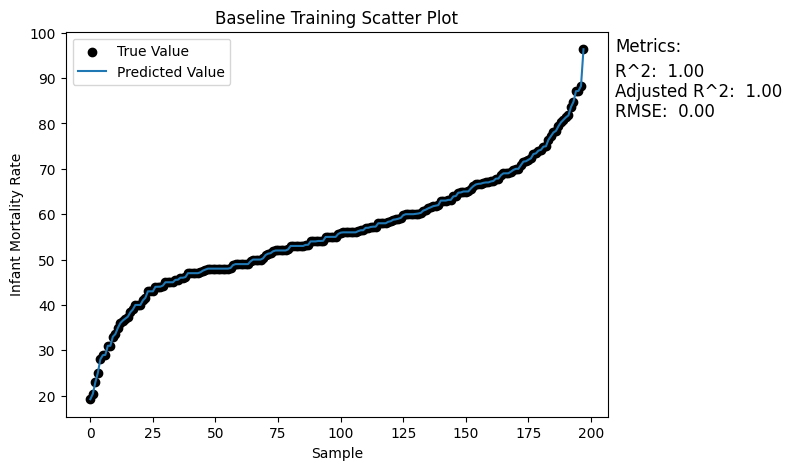

In [73]:
# Predicted vs true values
# Adds metrics to graph
plt.figure(figsize=(7,5))
plt.scatter(np.arange(len(X_train)),sorted(y_train.YY_Infant_Mortality_Rate_Imr_Total_Person), color='black', label='True Value')
plt.title('Baseline Training Scatter Plot')
plt.plot(np.arange(len(X_train)),ordered_preds_train, label = 'Predicted Value')
plt.figtext(0.91,0.84, 'Metrics:', size=12)
plt.figtext(0.91,0.79, f'R^2: {train_r2: 0.2f}', size=12)
plt.figtext(0.91,0.75, f'Adjusted R^2: {train_adj_r2: 0.2f}', size=12)
plt.figtext(0.91,0.71, f'RMSE: {train_RMSE: 0.2f}', size=12)
plt.ylabel('Infant Mortality Rate')
plt.xlabel('Sample')
plt.legend()
plt.show()

# Perfect training predictions

In [75]:
test_sorted_index = y_test.reset_index(drop=True).sort_values(by='YY_Infant_Mortality_Rate_Imr_Total_Person').index
ordered_preds_test = pd.DataFrame(base_preds_test).reindex(test_sorted_index).loc[:][0]

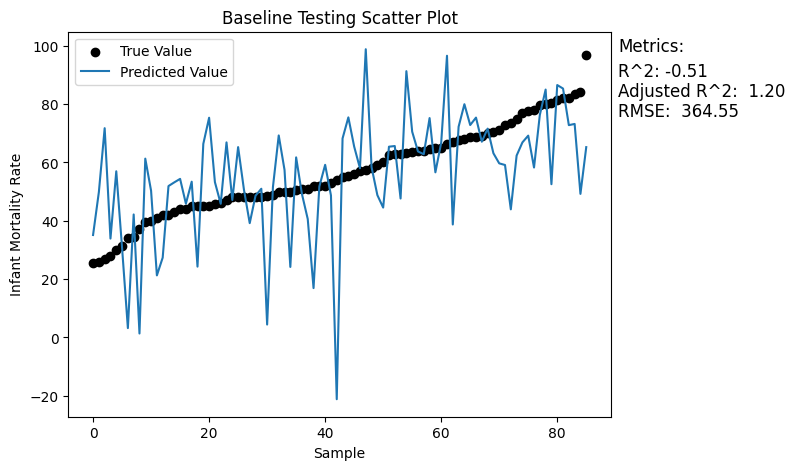

In [76]:
plt.figure(figsize=(7,5))
plt.scatter(np.arange(len(y_test)),sorted(y_test['YY_Infant_Mortality_Rate_Imr_Total_Person']), color='black', label='True Value')
plt.plot(np.arange(len(X_test)),ordered_preds_test, label='Predicted Value')
plt.title('Baseline Testing Scatter Plot')
plt.figtext(0.91,0.84, 'Metrics:', size=12)
plt.figtext(0.91,0.79, f'R^2: {test_r2: 0.2f}', size=12)
plt.figtext(0.91,0.75, f'Adjusted R^2: {test_adj_r2: 0.2f}', size=12)
plt.figtext(0.91,0.71, f'RMSE: {test_RMSE: 0.2f}', size=12)
plt.ylabel('Infant Mortality Rate')
plt.xlabel('Sample')
plt.legend()
plt.show()

# High variance in training predictions
# Model is severely overfitting

## EDA State Wise

In [77]:
target = 'YY_Infant_Mortality_Rate_Imr_Total_Person'

In [78]:
# Provided state-wise dataset
df_state = pd.read_csv('Key_indicator_statewise.csv')

In [79]:
states = list(df.State_Name.unique())
states

['Assam',
 'Bihar',
 'Chhattisgarh',
 'Jharkhand',
 'Madhya Pradesh',
 'Odisha',
 'Rajasthan',
 'Uttar Pradesh',
 'Uttarakhand']

In [84]:
# District data grouped by state
Assam,Bihar,Chhattisgarh,Jharkhand,Madhya_Preadesh,Odisha,Rajasthan,Uttar_Pradesh,Uttarakhand = df.groupby('State_Name', as_index=False)

# Split each state into an individual dataframe for exploration
Assam = Assam[1]
Bihar = Bihar[1]
Chhattisgarh = Chhattisgarh[1]
Jharkhand = Jharkhand[1]
Madhya_Preadesh = Madhya_Preadesh[1]
Odisha = Odisha[1]
Rajasthan = Rajasthan[1]
Uttar_Pradesh = Uttar_Pradesh[1]
Uttarakhand = Uttarakhand[1]

state_data = [Assam,Bihar,Chhattisgarh,Jharkhand,Madhya_Preadesh,Odisha,Rajasthan,Uttar_Pradesh,Uttarakhand]

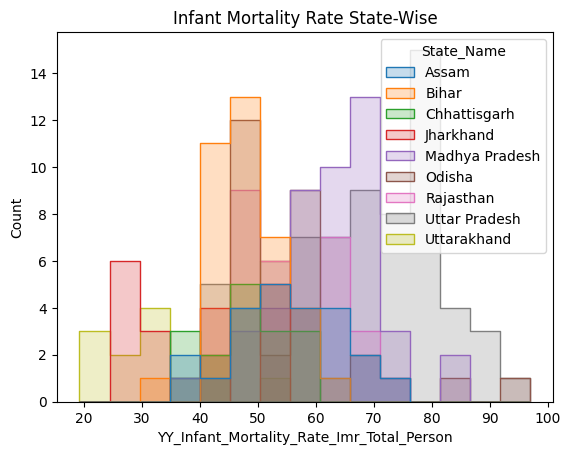

In [86]:
# IMR distributed statewise
sns.histplot(df, x = target, hue='State_Name', element='step')
plt.title('Infant Mortality Rate State-Wise')
plt.show()

# distributions differ, indicating state is a strong predictor

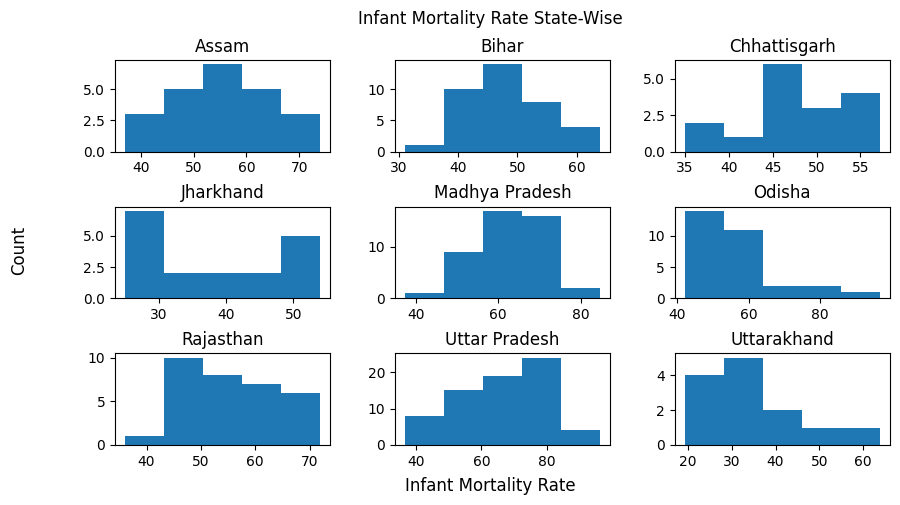

In [87]:
# State-wise distributions of IMR (target) separated
fig,axs = plt.subplots(3,3, figsize=(10,5))
plt.subplots_adjust(hspace=0.6, wspace=0.3)
r=0; c=0
for state in state_data:
    axs[c,r].hist(state[[target]], bins=5)
    axs[c,r].set_title(state['State_Name'].unique()[0])
    if r == 2:
        c+=1; r=0
    else:
        r+=1
fig.supxlabel('Infant Mortality Rate')
fig.supylabel('Count')
fig.suptitle('Infant Mortality Rate State-Wise')
plt.show()

# Preprocessing

## Null Values

In [47]:
row_nulls = dict(df.isna().sum(axis=1))
row_nulls # Null values row-wise

{0: 14,
 1: 14,
 2: 2,
 3: 188,
 4: 2,
 5: 14,
 6: 2,
 7: 14,
 8: 14,
 9: 192,
 10: 2,
 11: 2,
 12: 2,
 13: 194,
 14: 186,
 15: 186,
 16: 2,
 17: 2,
 18: 188,
 19: 2,
 20: 14,
 21: 2,
 22: 2,
 23: 186,
 24: 14,
 25: 186,
 26: 186,
 27: 2,
 28: 2,
 29: 2,
 30: 2,
 31: 2,
 32: 2,
 33: 186,
 34: 2,
 35: 186,
 36: 2,
 37: 14,
 38: 14,
 39: 14,
 40: 186,
 41: 188,
 42: 2,
 43: 14,
 44: 2,
 45: 14,
 46: 14,
 47: 2,
 48: 186,
 49: 186,
 50: 2,
 51: 14,
 52: 186,
 53: 2,
 54: 2,
 55: 186,
 56: 186,
 57: 14,
 58: 186,
 59: 2,
 60: 14,
 61: 2,
 62: 2,
 63: 2,
 64: 2,
 65: 14,
 66: 186,
 67: 186,
 68: 186,
 69: 2,
 70: 2,
 71: 2,
 72: 2,
 73: 2,
 74: 2,
 75: 14,
 76: 2,
 77: 14,
 78: 2,
 79: 2,
 80: 14,
 81: 186,
 82: 14,
 83: 186,
 84: 3,
 85: 2,
 86: 14,
 87: 2,
 88: 186,
 89: 2,
 90: 2,
 91: 2,
 92: 2,
 93: 2,
 94: 2,
 95: 2,
 96: 2,
 97: 2,
 98: 2,
 99: 2,
 100: 2,
 101: 2,
 102: 2,
 103: 2,
 104: 2,
 105: 186,
 106: 2,
 107: 2,
 108: 2,
 109: 2,
 110: 2,
 111: 2,
 112: 2,
 113: 15,
 114: 2,


In [88]:
# unique numbers of missing values across features
col_nulls = dict(df.isna().sum())
set(col_nulls.values())

# despite 198 features will null values, there are only 10 unique values for the
# number of missing null values. This indicates a potential pattern

{0, 1, 3, 9, 44, 45, 78, 92, 93, 284}

In [89]:
cols_44 = [] # Features with 44 null values
for k,v in col_nulls.items():
    if v == 44:
        cols_44.append(k)

In [90]:
cols_44

['JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Acute_Respiratory_Infection_Ari_Person_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Acute_Respiratory_Infection_Ari_Male_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Acute_Respiratory_Infection_Ari_Female_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Fever_All_Types_Person_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Fever_All_Types_Male_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Fever_All_Types_Female_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Any_Type_Of_Acute_Illness_Person_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Any_Type_Of_Acute_Illness_Male_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Any_Type_Of_Acute_Illness_Female_Urban',
 'JJ_Persons_Suffering_From_Acute_Illness_And_Taking_Treatment_From_Any_S

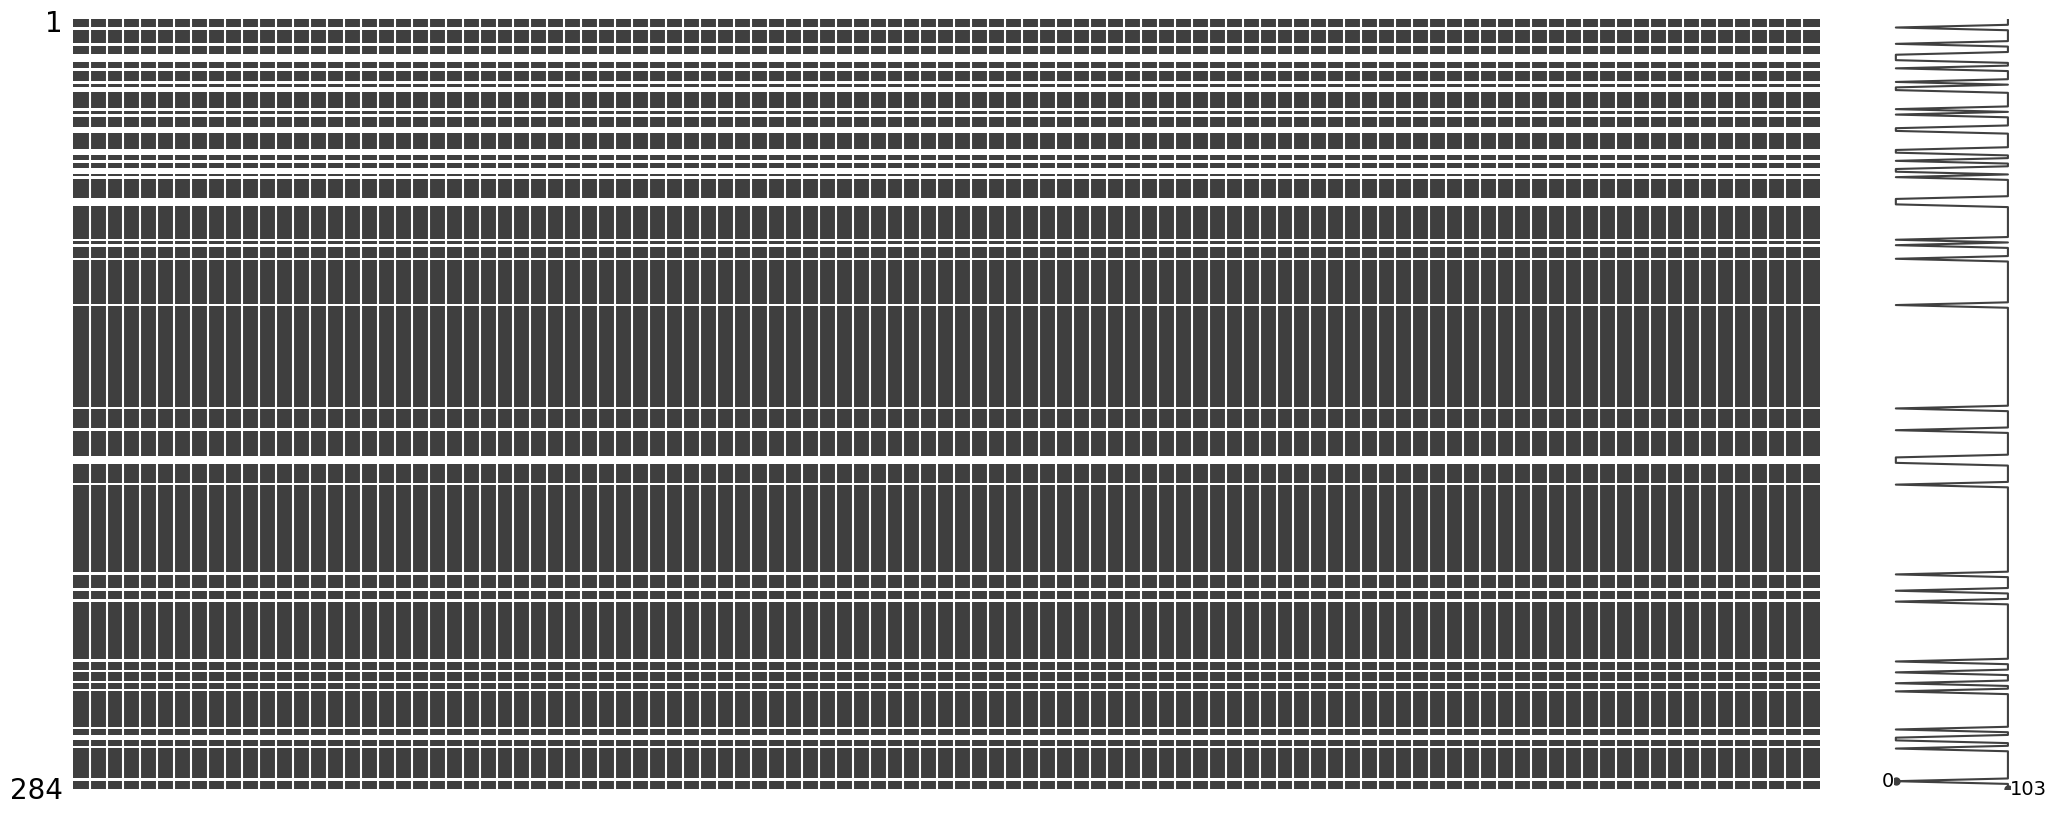

In [91]:
# Missingness matrix for features with 44 null values
msno.matrix(df[cols_44])
#plt.title('Missingness Matrics of Features Missing 44 values')
plt.show()

# A clearly uniform matrix: all of the features are missing information for the same districts

In [92]:
# Number of districts in each state
state_count=dict(df.State_Name.value_counts())
state_count

{'Uttar Pradesh': 70,
 'Madhya Pradesh': 45,
 'Bihar': 37,
 'Rajasthan': 32,
 'Odisha': 30,
 'Assam': 23,
 'Jharkhand': 18,
 'Chhattisgarh': 16,
 'Uttarakhand': 13}

In [93]:
# Proportion of null values state-wise
for k,v in state_count.items():
    print(k, round(df[df.State_Name==k][['NN_Current_Usage_Lam_Urban']].isna().sum().iloc[0]/v,2))

# States have an uneven proportion of null values
# This indicates that the state may share a relationship with the missing values

Uttar Pradesh 0.16
Madhya Pradesh 0.02
Bihar 0.35
Rajasthan 0.03
Odisha 0.17
Assam 0.26
Jharkhand 0.17
Chhattisgarh 0.19
Uttarakhand 0.08


In [94]:
cols_44.append('State_Name')

In [95]:
# Drop features with >70 null values
# Want to avoid overt imputation/synthetic data
for k,v in col_nulls.items():
    if v > 70:
        df = df.drop([k], axis=1)

In [96]:
df = df.fillna(-10000) # Fill nulls with a filler values

In [97]:
# state-based median imputation for remaining null values
for k,v in col_nulls.items():
    if v < 70 and v > 0:
        for state in df.State_Name.unique():
            median = df[df.State_Name==state][[k]].median().iloc[0]
            df[k] = np.where((df[k] == -10000) & (df['State_Name']== state), median, df[k])

In [99]:
df[df.State_Name=='Assam']['QQ_Safe_Delivery_Urban'].head()

0    87.3
1    90.7
2    84.3
3    84.8
4    84.5
Name: QQ_Safe_Delivery_Urban, dtype: float64

In [101]:
df.isna().sum() # Successful imputataion

State_Name                                 0
State_District_Name                        0
AA_Sample_Units_Total                      0
AA_Sample_Units_Rural                      0
AA_Sample_Units_Urban                      0
                                          ..
ZZ_Sex_Ratio_At_Birth_Total_Upper_Limit    0
ZZ_Sex_Ratio_At_Birth_Rural_Lower_Limit    0
ZZ_Sex_Ratio_At_Birth_Rural_Upper_Limit    0
ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit    0
ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit    0
Length: 608, dtype: int64

## Data Leakage

In [106]:
# All features with >0.7 correlatin with target were removed
sorted(dict(df.select_dtypes(include='number').corr()['YY_Infant_Mortality_Rate_Imr_Total_Person']).items(), key = lambda item: item[1])

[('TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total',
  -0.5447502905235537),
 ('TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Rural',
  -0.5424825638640728),
 ('TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Rural',
  -0.5255400882544962),
 ('TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Total',
  -0.524297292933966),
 ('TT_Children_Aged_12_23_Months_Who_Have_Received_Bcg_Total',
  -0.5239726984600177),
 ('TT_Children_Aged_12_23_Months_Who_Have_Received_Bcg_Rural',
  -0.5197321057657588),
 ('TT_Children_Aged_12_23_Months_Fully_Immunized_Rural', -0.5037178941789395),
 ('TT_Children_Aged_12_23_Months_Fully_Immunized_Total', -0.5022097019814096),
 ('TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural',
  -0.5011378072216273),
 ('TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total',
  -0.4990135075932253),
 ('AA_Ever_Married_Women_Aged_15_49_Years_T

In [107]:
# Features related to death and mortality
red = []
for c in df.columns:
    if 'Death' in c or 'Mortality' in c:
        red.append(c)

In [108]:
red

['YY_Crude_Death_Rate_Cdr_Total_Person',
 'YY_Crude_Death_Rate_Cdr_Total_Male',
 'YY_Crude_Death_Rate_Cdr_Total_Female',
 'YY_Crude_Death_Rate_Cdr_Rural_Person',
 'YY_Crude_Death_Rate_Cdr_Rural_Male',
 'YY_Crude_Death_Rate_Cdr_Rural_Female',
 'YY_Crude_Death_Rate_Cdr_Urban_Person',
 'YY_Crude_Death_Rate_Cdr_Urban_Male',
 'YY_Crude_Death_Rate_Cdr_Urban_Female',
 'YY_Infant_Mortality_Rate_Imr_Total_Person',
 'YY_Post_Neo_Natal_Mortality_Rate_Total',
 'YY_Post_Neo_Natal_Mortality_Rate_Rural',
 'ZZ_Crude_Death_Rate_Total_Lower_Limit',
 'ZZ_Crude_Death_Rate_Rural_Lower_Limit',
 'ZZ_Crude_Death_Rate_Rural_Upper_Limit',
 'ZZ_Crude_Death_Rate_Urban_Lower_Limit',
 'ZZ_Crude_Death_Rate_Urban_Upper_Limit']

In [65]:
#df.to_csv('postproc_comp.csv')